## IBM Telco - Churn Prediction (EM DESENVOLVIMENTO)

Este projeto foi desenvolvido com foco no desenvolvimento do meu portfólio de análise de dados, demonstrando minhas habilidades em Análise Exploratória de Dados com Python e utilização de estatística e previsão de churn, para gerar esta previsão em uma base de clientes. 

### Contexto de negócio
Utilizando-me de uma base de dados de cliente, com informações de contexto de negócio dos mesmos, temos o desafio de desenvolver um modelo de previsão de churn, ou seja, identificar clientes temos chances de perder, para que sejam tomadas ações antes que essa perda aconteça. Estou utilizando uma base de dados de clientes da IBM, fornecida por meio da Kaggle, https://www.kaggle.com/datasets/blastchar/telco-customer-churn.

### Perguntas de negócio a serem respondidas
    1. Quais clientes temos risco de perder? (churn)
    2. Porque temos riscos de perde-los?

### Etapas da Análise

- Importação de bibliotecas e carregamento dos dados
- Limpeza, tratamento e preparação
- Análise Exploratória de Dados (EDA)
- Aplicar os metodos de previsão
- Aplicar SHAP para entendimento dos motivos de churn.
- Conclusões 

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import kagglehub
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [2]:
# Download arquivo
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

# Listar todos os nomes dos arquivos na pasta
print(os.listdir(path))

Path to dataset files: C:\Users\diogo\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1
['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [3]:
df = pd.read_csv(path + '\\WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 🧹 Limpeza, tratamento e preparação


In [4]:
df['TotalCharges'] = df['TotalCharges'].replace(' ',float('nan'))
df['TotalCharges'] = df['TotalCharges'].astype('float64')
                                                
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [24]:
df = df.dropna()

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [25]:
print(df.duplicated().sum())
print(df.duplicated(subset=['customerID']).sum())  

0
0


In [26]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [27]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [28]:
# Conferir valores inconsistentes

for col in df.columns:
    print(f'{col}: {df[col].unique()}')


customerID: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender: ['Female' 'Male']
SeniorCitizen: [0 1]
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 '

### 🔎 Análise Exploratória de Dados (EDA)


In [29]:
# Agrupamento de dados
# Temos uma base boa para o modelo de churn > menor que 20%, de algum lado, necessita-se de atenção

churn_view = df.groupby('Churn')['customerID'].nunique().reset_index(name='quantity_clients')
churn_view['total_percent'] = (churn_view['quantity_clients'] / df['customerID'].nunique()) * 100
churn_view


,Churn,quantity_clients,total_percent
0,No,5163,73.421502
1,Yes,1869,26.578498


In [30]:
# Taxa de churn por caracteristica
# Colunas que considero interessantres de se analisar:
# gender, Dependents, internetservice, multiplelines, contract, paymentmethod, monthy charges
churn_gender = df.groupby(['Churn','gender'])['customerID'].nunique().reset_index(name='quantity_gender')
churn_gender['total_percent'] = (churn_gender['quantity_gender']/df['customerID'].nunique()) *100
churn_gender

# Vejo uma distribuição bem homogênea entre os sexos, portanto não será uma variavel relavante

,Churn,gender,quantity_gender,total_percent
0,No,Female,2544,36.177474
1,No,Male,2619,37.244027
2,Yes,Female,939,13.353242
3,Yes,Male,930,13.225256


In [31]:
# Analisando a variável InternetService
churn_service = (
    df.groupby(['Churn','InternetService'])
    .agg(
        quantity_service = ('customerID', 'nunique'),
        mean_month_charges = ('MonthlyCharges', 'mean')
    ).reset_index()
)
churn_service['total_percent'] = (churn_service['quantity_service']/df['customerID'].nunique())*100
churn_service.sort_values(by='total_percent')

# Nota-se que essa variável é importante, notamos que entre os "Churns" =Yes, 
# A maioria ocorre em clientes com tipo de serviço "Fiber optic"
# Provavelmente por serem clientes mais sensiveis a qualidade do serviço, do que DSL
# até mesmo porque em média ele paga quase o dobro do cliente DSL.

,Churn,InternetService,quantity_service,mean_month_charges,total_percent
5,Yes,No,113,20.368142,1.606940
3,Yes,DSL,459,49.083224,6.527304
4,Yes,Fiber optic,1297,88.126484,18.444255
2,No,No,1407,21.133156,20.008532
1,No,Fiber optic,1799,93.932379,25.583049
0,No,DSL,1957,60.200026,27.829920


In [32]:
churn_contract = df.groupby(['Churn','Contract'])['customerID'].nunique().reset_index(name='quantity_lines')
churn_contract['total_percent'] = (churn_contract['quantity_lines']/df['customerID'].nunique())*100
churn_contract.sort_values(by='Churn',ascending=False)

# Vejo uma clara tendência, de que pessoas que possuem o contrato 'Month-to-month', possuem churn discrepantemente maior.
# Provavlmente devido o cliente não estar "amarrado", acabe indo para concorrência.
# Neste caso seria interessante, a realização de ações voltadas para redução desse tipo de contrato.

,Churn,Contract,quantity_lines,total_percent
3,Yes,Month-to-month,1655,23.535267
4,Yes,One year,166,2.360637
5,Yes,Two year,48,0.682594
0,No,Month-to-month,2220,31.569966
1,No,One year,1306,18.572241
2,No,Two year,1637,23.279295


In [33]:
churn_payment = df.groupby(['Churn','PaymentMethod'])['customerID'].nunique().reset_index(name='quantity_clients')
churn_payment['total_percent'] = (churn_payment['quantity_clients']/df['customerID'].nunique())*100
churn_payment.sort_values(by=['Churn','total_percent'])

# Vejo uma clara tendência, de que pessoas que utilizam o metodo "Eletronic check", possuem churn discrepantemente maior.
# Como estratégia de diminuição desse tipo de churn, seria a busca por fazer com que estes clientes migrem de tipo de pagamento.
# notamos que o qualquer tipo dos demais, possuem alta aderência e ao mesmo tempo, igualmente, baixo churn.

,Churn,PaymentMethod,quantity_clients,total_percent
0,No,Bank transfer (automatic),1284,18.259386
1,No,Credit card (automatic),1289,18.330489
2,No,Electronic check,1294,18.401593
3,No,Mailed check,1296,18.430034
5,Yes,Credit card (automatic),232,3.299204
4,Yes,Bank transfer (automatic),258,3.668942
7,Yes,Mailed check,308,4.379977
6,Yes,Electronic check,1071,15.230375


In [34]:
# Utilizando ger_dummies, para transformação das colunas em binários, que considerei relevantes para correlacionar.
# Em formato de texto não funciona a correlação.

df_dummies = pd.get_dummies(
    df[['gender','Dependents','PhoneService','InternetService','StreamingTV','MultipleLines','Contract','PaymentMethod','Churn','tenure',
       'MonthlyCharges','TotalCharges']],
    columns=['gender','Dependents','PhoneService','InternetService','StreamingTV','MultipleLines','Contract','PaymentMethod','Churn'],
    #prefix='col',
    drop_first=True,
    dtype=int
)

df_corr = df_dummies.corr()
df_corr


,tenure,MonthlyCharges,TotalCharges,gender_Male,Dependents_Yes,PhoneService_Yes,InternetService_Fiber optic,InternetService_No,StreamingTV_No internet service,StreamingTV_Yes,MultipleLines_No phone service,MultipleLines_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
tenure,1.000000,0.246862,0.825880,0.005285,0.163386,0.007877,0.017930,-0.037529,-0.037529,0.280264,-0.007877,0.332399,0.202338,0.563801,0.232800,-0.210197,-0.232181,-0.354049
MonthlyCharges,0.246862,1.000000,0.651065,-0.013779,-0.112343,0.248033,0.787195,-0.763191,-0.763191,0.629668,-0.248033,0.490912,0.004810,-0.073256,0.030055,0.271117,-0.376568,0.192858
TotalCharges,0.825880,0.651065,1.000000,0.000048,0.064653,0.113008,0.360769,-0.374878,-0.374878,0.515709,-0.113008,0.469042,0.170569,0.358036,0.182663,-0.060436,-0.294708,-0.199484
gender_Male,0.005285,-0.013779,0.000048,1.000000,0.010349,-0.007515,-0.011189,0.004745,0.004745,-0.007124,0.007515,-0.008883,0.007755,-0.003603,0.001632,0.000844,0.013199,-0.008545
Dependents_Yes,0.163386,-0.112343,0.064653,0.010349,1.000000,-0.001078,-0.164101,0.138383,0.138383,-0.016499,0.001078,-0.024307,0.069222,0.201699,0.061134,-0.149274,0.056448,-0.163128
PhoneService_Yes,0.007877,0.248033,0.113008,-0.007515,-0.001078,1.000000,0.290183,0.171817,0.171817,-0.021383,-1.000000,0.279530,-0.003142,0.004442,-0.006916,0.002747,-0.004463,0.011691
InternetService_Fiber optic,0.017930,0.787195,0.360769,-0.011189,-0.164101,0.290183,1.000000,-0.465736,-0.465736,0.329744,-0.290183,0.366420,-0.076809,-0.209965,-0.050552,0.335763,-0.305984,0.307463
InternetService_No,-0.037529,-0.763191,-0.374878,0.004745,0.138383,0.171817,-0.465736,1.000000,1.000000,-0.414951,-0.171817,-0.210794,0.038061,0.217542,0.001870,-0.284608,0.319694,-0.227578
StreamingTV_No internet service,-0.037529,-0.763191,-0.374878,0.004745,0.138383,0.171817,-0.465736,1.000000,1.000000,-0.414951,-0.171817,-0.210794,0.038061,0.217542,0.001870,-0.284608,0.319694,-0.227578
StreamingTV_Yes,0.280264,0.629668,0.515709,-0.007124,-0.016499,-0.021383,0.329744,-0.414951,-0.414951,1.000000,0.021383,0.257804,0.061930,0.072124,0.040010,0.144747,-0.247712,0.063254


<function matplotlib.pyplot.show(close=None, block=None)>

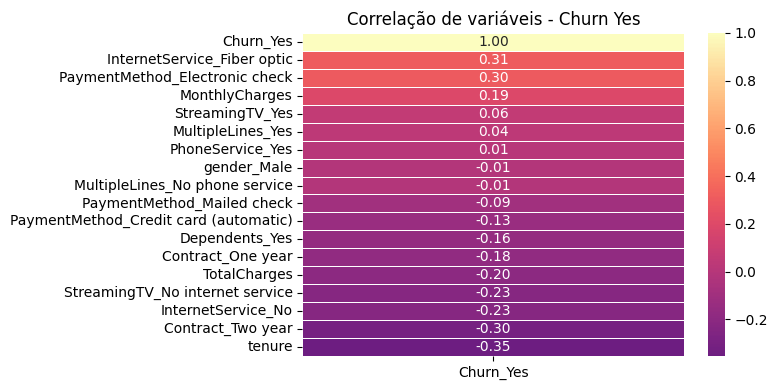

In [35]:
# Quanto mais alto o valor, mais diretamente proporcional se correlacionam as variaveis.
# Entendemos que Serviçlo de Fibra, Metodo de pagamento por Check são as variáveis com maior correlação nos clientes perdidos.
# Também notamos que quem tem mensalidades maiores, tem uma correlação em 3º lugar, mas correlação fraca.
# Ao mesmo tempo, quanto maior o tempo (tenure), pior é a correlação com Churn Yes > Fidelizar o cliente tende evitar Churn.
plt.figure(figsize=(8,4))

churn_corr = df_corr[['Churn_Yes']].sort_values('Churn_Yes', ascending=False)

sns.heatmap(
    churn_corr,
    annot=True,
    fmt='.2f',
    cmap='magma',
    center=0,
    linewidths=0.5
)

plt.title('Correlação de variáveis - Churn Yes')
plt.tight_layout()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

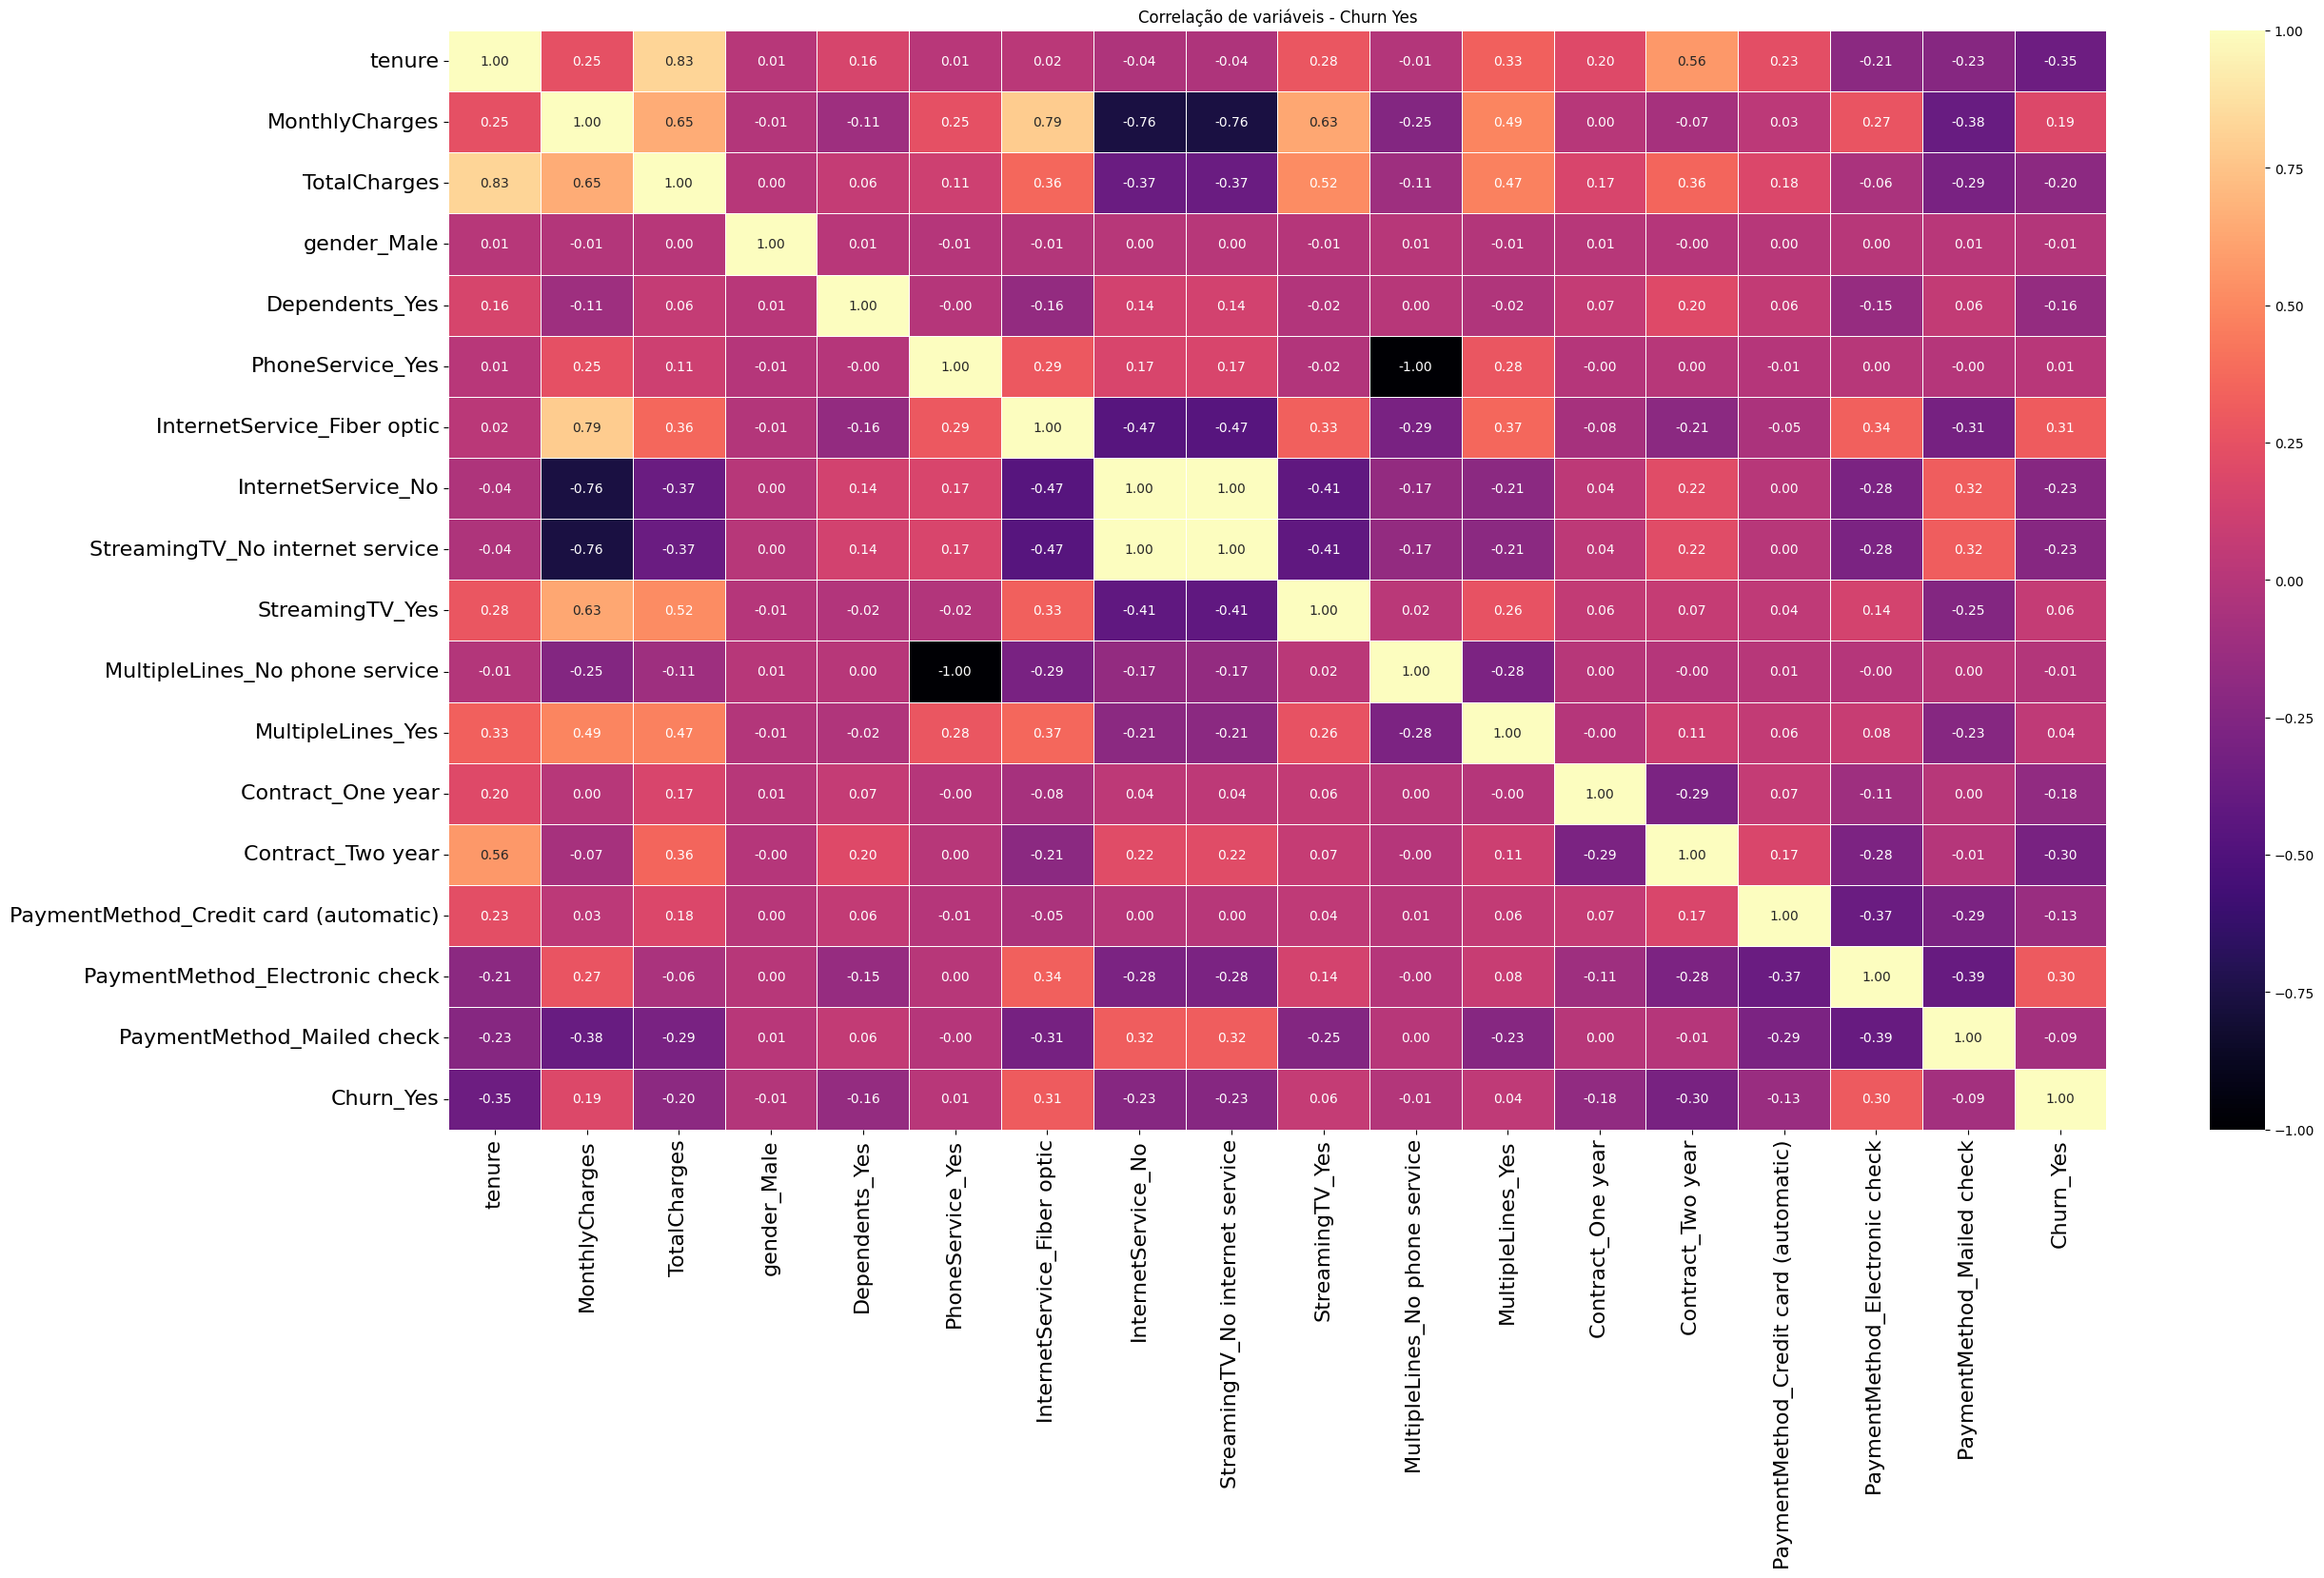

In [36]:
# tentativa de correlacionar mais variáveis, contudo, existe muita correlação financeira e com obviedades, 
# como quem tem fibra otica correlaciona com valor mensal 
plt.figure(figsize=(25,15))

churn_corr = df_corr

sns.heatmap(
    churn_corr,
    annot=True,
    fmt='.2f',
    cmap='magma',
    center=0,
    linewidths=0.5
)

plt.title('Correlação de variáveis - Churn Yes')
plt.tight_layout()
plt.yticks(fontsize=16)
plt.xticks(fontsize=16)
plt.show

### 🔎Aplicação de método de previsão
O Objetivo aqui será fazer um benchmark de modelos.
- Regressão Logistica
- Arvore de decisões
- Random Forest
- XGBoost

In [37]:
# from sklearn.model_selection import train_test_split 
x = df.drop(columns=['customerID','Churn'])
y = (df['Churn'] == 'Yes').astype(int)

# Transformando textos em números pois os modelos não entendem textos

x_encoded = pd.get_dummies(x, drop_first=True)

# Split df com sklearn
x_train, x_test, y_train, y_test = train_test_split(
    x_encoded, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [38]:
# Escalar os dados (especifico para regressão logistica)
# Colocar na mesma escala colunas com alto range

x_train_scaled =  StandardScaler().fit_transform(x_train)
x_test_scaled = StandardScaler().fit_transform(x_test)

In [39]:
# Treino, x escalado Vs respostas do y_train

model_logistic = LogisticRegression(max_iter=1000, random_state=42)
model_logistic.fit(x_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [40]:
# Previsão

y_pred = model_logistic.predict(x_test_scaled)
y_pred_proba = model_logistic.predict_proba(x_test_scaled)[:, 1]

# EM DESENVOLVIMENTO...